Loading Dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: (60000, 28, 28)
Testing samples: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Training Started...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9608 - loss: 0.1263 - val_accuracy: 0.9864 - val_loss: 0.0451
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9873 - loss: 0.0412 - val_accuracy: 0.9887 - val_loss: 0.0348
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9915 - loss: 0.0271 - val_accuracy: 0.9871 - val_loss: 0.0410
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9934 - loss: 0.0198 - val_accuracy: 0.9902 - val_loss: 0.0345
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9953 - loss: 0.0140 - val_accuracy: 0.9918 - val_loss: 0.0291
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9918 - loss: 0.0291
--------------------------
Test Accuracy: 0.9918000102043152
--------------------------


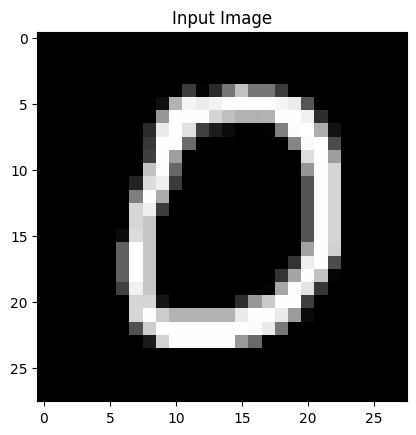

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


Predicted Digit: 0
Actual Digit: 0
Model Saved Successfully!


In [1]:

# Handwritten Character Recognition using CNN
# CodeAlpha Internship Project - Task 3

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------
# 1. Load MNIST Dataset
# -----------------------------

print("Loading Dataset...")

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training samples:", x_train.shape)
print("Testing samples:", x_test.shape)


# -----------------------------
# 2. Data Preprocessing
# -----------------------------

# Normalize data (0-255 to 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0


# Add channel dimension for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


# -----------------------------
# 3. Create CNN Model
# -----------------------------

model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),


    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),


    layers.Flatten(),


    layers.Dense(
        128,
        activation='relu'
    ),


    layers.Dense(
        10,
        activation='softmax'
    )
])


# Show model details
model.summary()


# -----------------------------
# 4. Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# -----------------------------
# 5. Train Model
# -----------------------------

print("Training Started...")

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)


# -----------------------------
# 6. Test Accuracy
# -----------------------------

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("--------------------------")
print("Test Accuracy:", accuracy)
print("--------------------------")


# -----------------------------
# 7. Prediction Example
# -----------------------------

index = 10

image = x_test[index]


plt.imshow(
    image.reshape(28,28),
    cmap="gray"
)

plt.title("Input Image")
plt.show()


prediction = model.predict(
    image.reshape(1,28,28,1)
)


predicted_digit = np.argmax(prediction)


print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[index])


# -----------------------------
# 8. Save Model
# -----------------------------

model.save("handwritten_character_model.h5")

print("Model Saved Successfully!")
